In [7]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study2.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'food_amount', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_tail', 'training_wing', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim_1', 'relevant_dim_2', 'irrelevant_dim', 'color_high', 'color_low', 'wing_high', 'wing_low', 'tail_high', 'tail_low', 'wing_discrete_slider.response', 'wing_direction_slider.response', 'wing_continuous_slider.response', 'color_discrete_slider.response', 'color_direction_slider.response', 'color_continuous_slider.response', 'tail_discrete_slider.response', 'tail_direction_slider.response', 'tail_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'food_amount', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_tail', 'training_wing', 'training_color', 'testing_categories', 'c

In [8]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_tail', 'training_wing', 'training_color', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['food_amount'] = df_accommodate['food_amount'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['food_amount'] = df_predict['food_amount'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
df_combined['participant'] = range(1, len(df_combined) + 1)



In [9]:
# Load explanation coding
coding_path = os.path.join(
    topdir,
    "data/Combined/explanationcodes/Explanation_Coding_Study2.csv"
)

df_coding = pd.read_csv(coding_path)

# Drop empty rows 
df_coding = df_coding.dropna(subset=["participant"]).copy()

# Convert participant IDs (unique condition order identifiers)
df_coding["participant"] = df_coding["participant"].astype(int)
df_accommodate["participant"] = df_accommodate["participant"].astype(int)

# Treat blank cells as 0, coded cells as 1
coding_cols = ["None", "Causal_Explanation", 
               "Color", "Tail", "Wing", 'All']

for col in coding_cols:
    df_coding[col] = df_coding[col].fillna(0)
    df_coding[col] = df_coding[col].replace("", 0)
    df_coding[col] = df_coding[col].astype(int)


# Category Mapping:
# None / Explanation / Causal_Explanation only -> none
# Color -> Color
# Tail -> Tail
# stripes+Tail -> both

# Broad causal flag: marked causal OR feature-specific causal
df_coding["causal_color"] = (
    df_coding["Color"].eq(1)
    | df_coding["All"].eq(1)
)

df_coding["causal_tail"] = (
    df_coding["Tail"].eq(1)
    | df_coding["All"].eq(1)
)

df_coding["causal_wing"] = (
    df_coding["Wing"].eq(1)
    | df_coding["All"].eq(1)
)

# Broad causal flag
df_coding["has_causal_explanation"] = (
    df_coding["Causal_Explanation"].eq(1)
    | df_coding["causal_color"]
    | df_coding["causal_tail"]
    | df_coding["causal_wing"]
)

df_accommodate = df_accommodate.merge(
    df_coding[
        [
            "participant",
            "has_causal_explanation",
            "causal_color",
            "causal_tail",
            "causal_wing",
        ]
    ],
    on="participant",
    how="left"
)

# Participants not in coding file default to none
df_accommodate["has_causal_explanation"] = df_accommodate["has_causal_explanation"].fillna(False)
df_accommodate["causal_color"] = df_accommodate["causal_color"].fillna(False)
df_accommodate["causal_tail"] = df_accommodate["causal_tail"].fillna(False)
df_accommodate["causal_wing"] = df_accommodate["causal_wing"].fillna(False)

In [10]:
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)

In [11]:
participant_id = 11

row = df_accommodate.loc[
    df_accommodate["participant"] == participant_id
].iloc[0]

print(f"Participant: {participant_id}")
#print(f"Explanation type: {row['explanation_type']}")
print(f"Has causal explanation: {row['has_causal_explanation']}")
print(f"Causal tail: {row['causal_tail']}")
print(f"Causal color: {row['causal_color']}")
print(f"Causal wing: {row['causal_wing']}")
print("\n--- FREE TEXTS ---\n")

import ast

free_texts = row["free_texts"]

if isinstance(free_texts, str):
    free_texts = ast.literal_eval(free_texts)

for text in free_texts:
    print(text)
    print()

Participant: 11
Has causal explanation: True
Causal tail: True
Causal color: False
Causal wing: False

--- FREE TEXTS ---

blue, 4 legs and it has a tail and ears. So it eats a decent amount to maintain these features.

tail is no longer slightly curled so it needs less energy so it eats one less than the other sperk

has two legs so less legs but instead has wings, so it makes up for it by eating the same amount of food. It is also yellow and thus a brighter color, so even with the flat tail it will eat the same as the first blue sperk.

This is bascially identical to the first blue sperk but yellow meaning that it must be the yellow that makes the sperk eat way more food(2).

it now has wings, so it needs to eat more than before, even though it doesn't have the two front legs anymore. Thus it eats slightly more at 6

curled tail so it must mean that the curled tail conserves energy for the yellow sperks. and thus eats less food even with the wings.

Yellow sperk with flat tail eats 7

In [14]:

df_combined = pd.concat(
    [df_accommodate, df_predict],
    ignore_index=True
)

df_combined['participant'] = range(1, len(df_combined) + 1)
participant_rows = []

for _, row in df_combined.iterrows():

    tail_yes = (
        1 if row['tail_discrete_slider.response'] == 'Yes' else 0
    )
    shape_yes = (
        1 if row['wing_discrete_slider.response'] == 'Yes' else 0
    )
    color_yes = (
        1 if row['color_discrete_slider.response'] == 'Yes' else 0
    )

    model_param_score = (
        tail_yes +
        shape_yes +
        color_yes
    )

    # Create 3-level explanation group
    if row['task'] == 'predict':
        explanation_group = 'predictor'

    elif row['has_causal_explanation'] == True:
        explanation_group = 'causal_explainer'

    else:
        explanation_group = 'non_explainer'

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],
        'explanation_group': explanation_group,
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'overfit': model_param_score == 3,
        'irrelevant_dim': row['irrelevant_dim']
    })

df_params = pd.DataFrame(participant_rows)
df_params.to_csv(
    os.path.join(
        outputdirCombined,
        "df_params_by_explanation_for_R-Study2.csv"
    ),
    index=False
)
contingency = pd.crosstab(
    df_params['explanation_group'],
    df_params['overfit']
)

print("\nContingency table:")
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print("\nOmnibus chi-square:")
print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

print("\nExpected counts:")
print(
    pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    )
)


Contingency table:
overfit            False  True 
explanation_group              
causal_explainer      19     18
non_explainer         97     75
predictor            121     88

Omnibus chi-square:
Chi-square = 0.559
df = 2
p-value = 0.7561

Expected counts:
overfit                 False      True 
explanation_group                       
causal_explainer    20.978469  16.021531
non_explainer       97.521531  74.478469
predictor          118.500000  90.500000


In [15]:
# Create map from feature response labels to internal short codes

wing_map = {
    "wings": "t",
    "paws": "n",
}

color_map = {
    "blue": "b",
    "yellow": "y",
}

tail_map = {
    "curly": "c",
    "straight": "s",
}

feature_maps = {
    "wing": wing_map,
    "color": color_map,
    "tail": tail_map,
}


# Compute feature importance scores

def compute_feature_importance_from_df(df):
    """
    Compute numeric feature-importance scores from -7 to 7.

    A score of 0 indicates that the participant said the feature was not
    relevant, did not respond, or selected a direction that could not be
    matched to the stored high/low feature values.
    """

    df = df.copy()
    features = ["wing", "color", "tail"]

    def normalize_str(value):
        """Strip whitespace, collapse repeated spaces, and lowercase strings."""
        if isinstance(value, str):
            return " ".join(value.split()).lower()
        return ""

    def compute_row_importance(row, feat):
        disc = row[f"{feat}_discrete_slider.response"]
        direction = row[f"{feat}_direction_slider.response"]
        continuous = row[f"{feat}_continuous_slider.response"]

        # If the participant said the feature was not relevant,
        # or did not answer, importance is zero
        if disc == "No" or pd.isna(disc):
            return 0.0

        # Missing continuous response defaults to zero
        cont_val = float(continuous) if not pd.isna(continuous) else 0.0

        mapping = feature_maps.get(feat, {})

        direction_norm = normalize_str(direction)
        internal_direction = mapping.get(direction_norm)

        high_val = normalize_str(row[f"{feat}_high"])
        low_val = normalize_str(row[f"{feat}_low"])

        # Positive if the selected direction matches the true high value
        if internal_direction == high_val:
            sign = 1

        # Negative if the selected direction matches the true low value
        elif internal_direction == low_val:
            sign = -1

        # Unmatched or missing response
        else:
            sign = 0
            cont_val = 0.0

        return cont_val * sign

    for feat in features:
        df[f"{feat}_importance"] = df.apply(
            lambda row: compute_row_importance(row, feat),
            axis=1,
        )

    return df


df_combined = compute_feature_importance_from_df(df_combined)


# Create explanation groups:
# predict
# accommodate_causal
# accommodate_none

df_combined["task_explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),
        (
            df_combined["task"].eq("accommodate")
            & df_combined["has_causal_explanation"].fillna(False)
        ),
        (
            df_combined["task"].eq("accommodate")
            & ~df_combined["has_causal_explanation"].fillna(False)
        ),
    ],
    [
        "predict",
        "accommodate_causal",
        "accommodate_none",
    ],
    default=pd.NA,
)


# Reshape to long format:
# one row per participant × feature dimension

cols_to_keep = [
    "participant",
    "task",
    "task_explanation_group",
    "tail_importance",
    "color_importance",
    "wing_importance",
    "has_causal_explanation",
    "causal_tail",
    "causal_color",
    "causal_wing",
    "relevant_dim_1",
    "relevant_dim_2",
    "irrelevant_dim",
    "color_high",
    "wing_high",
    "tail_discrete_slider.response",
    "wing_discrete_slider.response",
]

df_long = df_combined[cols_to_keep].copy()

df_long = df_long.melt(
    id_vars=[
        "participant",
        "task",
        "task_explanation_group",
        "has_causal_explanation",
        "causal_tail",
        "causal_color",
        "causal_wing",
        "relevant_dim_1",
        "relevant_dim_2",
        "irrelevant_dim",
        "color_high",
        "wing_high",
        "tail_discrete_slider.response",
        "wing_discrete_slider.response",
    ],
    value_vars=[
        "tail_importance",
        "color_importance",
        "wing_importance",
    ],
    var_name="feature_dimension",
    value_name="feature_importance",
)

# Simplify feature-dimension names
df_long["feature_dimension"] = (
    df_long["feature_dimension"]
    .str.replace("_importance", "", regex=False)
)


# Create row-level indicator:
# Did this participant provide a causal explanation for this specific feature?

df_long["had_causal_explanation_for_feature"] = np.select(
    [
        df_long["feature_dimension"].eq("tail"),
        df_long["feature_dimension"].eq("color"),
        df_long["feature_dimension"].eq("wing"),
    ],
    [
        df_long["causal_tail"].fillna(False),
        df_long["causal_color"].fillna(False),
        df_long["causal_wing"].fillna(False),
    ],
    default=False,
).astype(bool)

# Predictors should always be False
df_long["had_causal_explanation_for_feature"] = (
    df_long["had_causal_explanation_for_feature"]
    & df_long["task"].eq("accommodate")
)


# Create the three-level grouping:
# predictor
# explainer
# non_explainer

df_long["feature_explanation_group"] = np.select(
    [
        df_long["task"].eq("predict"),
        (
            df_long["task"].eq("accommodate")
            & df_long["had_causal_explanation_for_feature"]
        ),
        (
            df_long["task"].eq("accommodate")
            & ~df_long["had_causal_explanation_for_feature"]
        ),
    ],
    [
        "predictor",
        "explainer",
        "non_explainer",
    ],
    default=pd.NA,
)


# Determine whether each feature was relevant or irrelevant

df_long["feature_relevance"] = np.where(
    df_long.apply(
        lambda row: row["feature_dimension"]
        in [row["relevant_dim_1"], row["relevant_dim_2"]],
        axis=1,
    ),
    "relevant",
    "irrelevant",
)


# Optional checks


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_56154/3862912425.py:103: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_56154/3862912425.py:107: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_56154/3862912425.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in 

In [16]:
print(
    df_long.groupby(
        ["feature_dimension", "feature_explanation_group"],
        dropna=False,
    ).size()
)

print(
    df_long.loc[
        df_long["participant"].eq(31),
        [
            "participant",
            "task",
            "feature_dimension",
            "causal_color",
            "causal_tail",
            "causal_wing",
            "had_causal_explanation_for_feature",
            "feature_explanation_group",
            "feature_importance",
            "feature_relevance",
        ],
    ].sort_values("feature_dimension")
)

feature_dimension  feature_explanation_group
color              explainer                     10
                   non_explainer                199
                   predictor                    209
tail               explainer                     10
                   non_explainer                199
                   predictor                    209
wing               explainer                     32
                   non_explainer                177
                   predictor                    209
dtype: int64
     participant         task feature_dimension causal_color causal_tail  \
448           31  accommodate             color        False       False   
30            31  accommodate              tail        False       False   
866           31  accommodate              wing        False       False   

    causal_wing  had_causal_explanation_for_feature feature_explanation_group  \
448       False                               False             non_explainer   
30     

In [17]:
df_long.groupby(
    ["task",  "had_causal_explanation_for_feature"],
    dropna=False
).size()

task         had_causal_explanation_for_feature
accommodate  False                                 575
             True                                   52
predict      False                                 627
dtype: int64

In [18]:
participant_summary = (
    df_long[["participant", "task", "has_causal_explanation"]]
    .drop_duplicates()
)

participant_summary["has_causal_explanation"].value_counts()

has_causal_explanation
False    172
True      37
Name: count, dtype: int64

In [19]:
df_long.groupby(
    ["task", "feature_dimension", "had_causal_explanation_for_feature"],
    dropna=False
).size()

task         feature_dimension  had_causal_explanation_for_feature
accommodate  color              False                                 199
                                True                                   10
             tail               False                                 199
                                True                                   10
             wing               False                                 177
                                True                                   32
predict      color              False                                 209
             tail               False                                 209
             wing               False                                 209
dtype: int64

In [20]:
df_long.to_csv(os.path.join(outputdirCombined, 'df_long_by_explanation_for_R-Study2.csv'), index=False)

In [13]:
# Features included in the overfitting/relevance count
features = ["tail", "color", 'wing']

discrete_cols = [
    f"{feat}_discrete_slider.response"
    for feat in features
]

# Inspect the response values before recoding
for col in discrete_cols:
    print(f"\nValues in {col}:")
    print(df_combined[col].value_counts(dropna=False))


Values in tail_discrete_slider.response:
tail_discrete_slider.response
Yes    320
No      98
Name: count, dtype: int64

Values in color_discrete_slider.response:
color_discrete_slider.response
Yes    303
No     115
Name: count, dtype: int64

Values in wing_discrete_slider.response:
wing_discrete_slider.response
Yes    301
No     117
Name: count, dtype: int64


   explanation_group  n_features_endorsed  n_participants  percentage
0          Predictor                    0              11    5.263158
1          Predictor                    1              25   11.961722
2          Predictor                    2              85   40.669856
3          Predictor                    3              88   42.105263
4      Non-explainer                    0               6    3.488372
5      Non-explainer                    1              21   12.209302
6      Non-explainer                    2              70   40.697674
7      Non-explainer                    3              75   43.604651
8          Explainer                    0               4   10.810811
9          Explainer                    1               5   13.513514
10         Explainer                    2              10   27.027027
11         Explainer                    3              18   48.648649


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37770/4206140239.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37770/4206140239.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~df_combined["has_causal_explanation"].fillna(False)


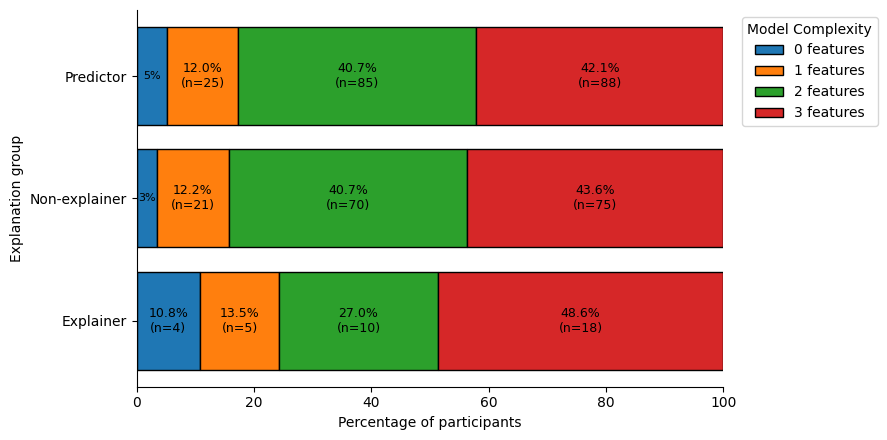

In [14]:
# Convert Yes/No response to 'does this feature matter' into 1/0 indicators
for feat in features:
    response_col = f"{feat}_discrete_slider.response"
    endorsed_col = f"{feat}_endorsed"

    df_combined[endorsed_col] = (
        df_combined[response_col]
        .astype("string")
        .str.strip()
        .str.lower()
        .eq("yes")
        .astype(int)
    )

# Total number of features judged relevant: 0, 1, 2, or 3
df_combined["n_features_endorsed"] = (
    df_combined["tail_endorsed"]
    + df_combined["color_endorsed"]
    + df_combined["wing_endorsed"]
)

# Create a new column for explanation group, based on task and causal explanation status
df_combined["explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),

        (
            df_combined["task"].eq("accommodate")
            & df_combined["has_causal_explanation"].fillna(False)
        ),

        (
            df_combined["task"].eq("accommodate")
            & ~df_combined["has_causal_explanation"].fillna(False)
        ),
    ],
    [
        "Predictor",
        "Explainer",
        "Non-explainer",
    ],
    default=pd.NA,
)
# Create a unique identifier for each participant × task combination
df_combined["participant_task_id"] = (
    df_combined["participant"].astype(str)
    + "_"
    + df_combined["task"].astype(str)
)
overfit_df = df_combined[
    [
        "participant",
        "participant_task_id",
        "task",
        "explanation_group",
        "tail_endorsed",
        "color_endorsed",
        "wing_endorsed",
        "n_features_endorsed",
        "relevant_dim_1",
        "irrelevant_dim",
    ]
].copy()

# Plotting order
group_order = [
    "Predictor",
    "Non-explainer",
    "Explainer",
]

score_order = [0, 1, 2, 3]


# Count participants at each score within each group
overfit_percentages = (
    overfit_df
    .dropna(
        subset=[
            "explanation_group",
            "n_features_endorsed",
        ]
    )
    .groupby(
        [
            "explanation_group",
            "n_features_endorsed",
        ],
        observed=True
    )
    .agg(
        n_participants=(
            "participant_task_id",
            "nunique"
        )
    )
    .reset_index()
)


# If a group has no participants with a given score, we want to fill in that row with 0 participants
full_index = pd.MultiIndex.from_product(
    [
        group_order,
        score_order,
    ],
    names=[
        "explanation_group",
        "n_features_endorsed",
    ]
)

overfit_percentages = (
    overfit_percentages
    .set_index(
        [
            "explanation_group",
            "n_features_endorsed",
        ]
    )
    .reindex(
        full_index,
        fill_value=0
    )
    .reset_index()
)


# Calculate percentage within each explanation group
overfit_percentages["percentage"] = (
    overfit_percentages["n_participants"]
    / overfit_percentages
        .groupby("explanation_group")["n_participants"]
        .transform("sum")
    * 100
)

print(overfit_percentages)

count_wide = (
    overfit_percentages
    .pivot(
        index="explanation_group",
        columns="n_features_endorsed",
        values="n_participants"
    )
    .reindex(group_order)
    .reindex(columns=[0, 1, 2, 3], fill_value=0)
    .fillna(0)
)

# Convert long percentages table to wide format:
# one row per group, one column for each score
percentage_wide = (
    overfit_percentages
    .pivot(
        index="explanation_group",
        columns="n_features_endorsed",
        values="percentage"
    )
    .reindex(group_order)
    .reindex(columns=[0, 1, 2, 3], fill_value=0)
    .fillna(0)
)


fig, ax = plt.subplots(figsize=(9, 4.5))

left = np.zeros(len(percentage_wide))
#Plot horizontal stacked bar chart
for score in [0, 1, 2, 3]:
    percentages = percentage_wide[score].to_numpy()
    counts = count_wide[score].to_numpy()

    bars = ax.barh(
        y=percentage_wide.index,
        width=percentages,
        left=left,
        edgecolor="black",
        label=f"{score} features",
    )

    for bar, percentage, count, starting_point in zip(
        bars,
        percentages,
        counts,
        left,
    ):
        if percentage >= 8:
            ax.text(
                starting_point + percentage / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.1f}%\n(n={int(count)})",
                ha="center",
                va="center",
                fontsize=9,
            )
        elif percentage > 0:
            ax.text(
                starting_point + percentage / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
            )

    left += percentages

ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of participants")
ax.set_ylabel("Explanation group")
ax.set_xticks(np.arange(0, 101, 20))
ax.invert_yaxis()

ax.legend(
    title="Model Complexity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
df_wing = df_long[df_long["feature_dimension"] == "wing"].copy()
df_wing["wing_relevant"] = (df_wing["feature_relevance"] == "relevant").astype(int) #Code relevancy as 0/1
df_wing["wing_high"] = (df_wing["wing_high"] == "T").astype(int) #Code having a wing as 0/1
print(df_wing)
df_wing.to_csv(os.path.join(outputdirCombined, 'df_wing_byexplanation_for_R-Study2.csv'), index=False)

      participant         task task_explanation_group has_causal_explanation  \
836           216  accommodate       accommodate_none                  False   
837            31  accommodate     accommodate_causal                   True   
838           142  accommodate     accommodate_causal                   True   
839            18  accommodate       accommodate_none                  False   
840            62  accommodate       accommodate_none                  False   
...           ...          ...                    ...                    ...   
1249          183      predict                predict                    NaN   
1250          178      predict                predict                    NaN   
1251          172      predict                predict                    NaN   
1252            4      predict                predict                    NaN   
1253           18      predict                predict                    NaN   

     causal_tail causal_color causal_wi

In [16]:

# Average training food score for each item and participant
training_cols = [
    "participant",
    "task",
    "training_image_order",
    "food_amount",
]

df_train = df_combined[training_cols].copy()

df_train_long = (
    df_train
    .explode(
        [
            "training_image_order",
            "food_amount",
        ]
    )
    .rename(
        columns={
            "training_image_order": "item"
        }
    )
)

# Ensure food scores are numeric
df_train_long["food_amount"] = pd.to_numeric(
    df_train_long["food_amount"],
    errors="coerce",
)

avg_food_train = (
    df_train_long
    .groupby(
        [
            "participant",
            "task",
            "item",
        ],
        as_index=False,
    )["food_amount"]
    .mean()
)


# ------------------------------------------------------------
# Reshape test responses to one row per participant × test item
# ------------------------------------------------------------

testing_cols = [
    "participant",
    "task",
    "testing_image_order",
    "testing_responses",
    "relevant_dim_1",
    "relevant_dim_2",
    "irrelevant_dim",
    "color_high",
    "tail_high",
    "wing_high",
    "has_causal_explanation",
    "causal_color",
    "causal_tail",
    "causal_wing",
]

df_test = df_combined[testing_cols].copy()

df_test_long = (
    df_test
    .explode(
        [
            "testing_image_order",
            "testing_responses",
        ]
    )
    .rename(
        columns={
            "testing_image_order": "item"
        }
    )
)

# Ensure test responses are numeric
df_test_long["testing_responses"] = pd.to_numeric(
    df_test_long["testing_responses"],
    errors="coerce",
)


# ------------------------------------------------------------
# Merge test scores with average training food
# ------------------------------------------------------------

df_merged = df_test_long.merge(
    avg_food_train,
    on=[
        "participant",
        "task",
        "item",
    ],
    how="left",
    validate="many_to_one",
)


# Compute signed and absolute prediction error
df_merged["error"] = (
    df_merged["testing_responses"]
    - df_merged["food_amount"]
)

df_merged["abs_error"] = df_merged["error"].abs()


# ------------------------------------------------------------
# Extract the feature values from each item code (structued as color_tail_wing)
# ------------------------------------------------------------

# Assumes item names have the structure:
# color_tail_wing
df_merged[
    [
        "wing",
        "color",
        "tail",
    ]
] = (
    df_merged["item"]
    .astype(str)
    .str.split("_", expand=True)
)


# Indicators for whether each item contains the participant's
# high value for each feature
df_merged["color_match_high"] = (
    df_merged["color"].astype(str)
    == df_merged["color_high"].astype(str)
).astype(int)

df_merged["tail_match_high"] = (
    df_merged["tail"].astype(str)
    == df_merged["tail_high"].astype(str)
).astype(int)

df_merged["wing_match_high"] = (
    df_merged["wing"].astype(str)
    == df_merged["wing_high"].astype(str)
).astype(int)


# ------------------------------------------------------------
# Compute one correlation per participant × feature
# ------------------------------------------------------------

participant_corrs = []

for (participant, task), g in df_merged.groupby(
    [
        "participant",
        "task",
    ]
):
    for feat in [
        "color",
        "tail",
        "wing",
    ]:
        match_col = f"{feat}_match_high"
        high_col = f"{feat}_high"
        causal_col = f"causal_{feat}"

        # Use only complete observations for this correlation
        corr_data = g[
            [
                "testing_responses",
                match_col,
            ]
        ].dropna()

        # Correlation requires variation in both variables
        if (
            len(corr_data) >= 2
            and corr_data["testing_responses"].nunique() > 1
            and corr_data[match_col].nunique() > 1
        ):
            corr = corr_data["testing_responses"].corr(
                corr_data[match_col]
            )
        else:
            corr = np.nan

        # A feature is relevant if it matches either relevant dimension
        relevant_dimensions = {
            g["relevant_dim_1"].iloc[0],
            g["relevant_dim_2"].iloc[0],
        }

        feature_relevance = (
            "relevant"
            if feat in relevant_dimensions
            else "irrelevant"
        )

        # Determine whether this participant explained this feature
        if task == "predict":
            had_causal_explanation_for_feature = False
        else:
            had_causal_explanation_for_feature = bool(
                g[causal_col]
                .fillna(False)
                .iloc[0]
            )

        # Feature-relative grouping
        if task == "predict":
            feature_explanation_group = "predictor"

        elif had_causal_explanation_for_feature:
            feature_explanation_group = "explainer"

        else:
            feature_explanation_group = "non_explainer"

        participant_corrs.append(
            {
                "participant": participant,
                "task": task,

                # Broad participant-level explanation status
                "has_causal_explanation": bool(
                    g["has_causal_explanation"]
                    .fillna(False)
                    .iloc[0]
                ),

                # Feature-specific explanation indicators
                "causal_color": bool(
                    g["causal_color"]
                    .fillna(False)
                    .iloc[0]
                ),
                "causal_tail": bool(
                    g["causal_tail"]
                    .fillna(False)
                    .iloc[0]
                ),
                "causal_wing": bool(
                    g["causal_wing"]
                    .fillna(False)
                    .iloc[0]
                ),

                # Row-specific explanation classification
                "had_causal_explanation_for_feature":
                    had_causal_explanation_for_feature,

                "feature_explanation_group":
                    feature_explanation_group,

                "feature_dimension": feat,
                "feature_relevance": feature_relevance,
                "high_value": g[high_col].iloc[0],
                "irrelevant_dim": g["irrelevant_dim"].iloc[0],

                "correlation": corr,
                "abs_correlation": (
                    abs(corr)
                    if pd.notna(corr)
                    else np.nan
                ),
            }
        )


df_corr = pd.DataFrame(participant_corrs)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

print(
    df_corr.groupby(
        [
            "feature_dimension",
            "feature_explanation_group",
        ],
        dropna=False,
    ).size()
)

print(
    df_corr.groupby(
        [
            "feature_dimension",
            "feature_relevance",
            "feature_explanation_group",
        ],
        dropna=False,
    ).size()
)


# Inspect participants classified as explainers for each feature
print(
    df_corr.loc[
        df_corr["had_causal_explanation_for_feature"],
        [
            "participant",
            "task",
            "feature_dimension",
            "causal_color",
            "causal_tail",
            "causal_wing",
            "feature_explanation_group",
            "feature_relevance",
            "correlation",
        ],
    ].sort_values(
        [
            "feature_dimension",
            "participant",
        ]
    )
)


# Each participant should have exactly three rows:
# color, tail, and wing
print(
    df_corr.groupby("participant")
    .size()
    .value_counts()
)


# ------------------------------------------------------------
# Save for R
# ------------------------------------------------------------

output_path = os.path.join(
    topdir,
    "data/Combined/df_corr_by_explanation_for_R-Study2.csv"
)

df_corr.to_csv(
    output_path,
    index=False,
)

print(f"Saved df_corr to:\n{output_path}")

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37770/2223051889.py:212: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37770/2223051889.py:234: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37770/2223051889.py:241: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to t

feature_dimension  feature_explanation_group
color              explainer                     10
                   non_explainer                199
                   predictor                    209
tail               explainer                     10
                   non_explainer                199
                   predictor                    209
wing               explainer                     32
                   non_explainer                177
                   predictor                    209
dtype: int64
feature_dimension  feature_relevance  feature_explanation_group
color              irrelevant         explainer                      3
                                      non_explainer                 49
                                      predictor                     52
                   relevant           explainer                      7
                                      non_explainer                150
                                      predictor        

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37770/2223051889.py:212: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37770/2223051889.py:234: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37770/2223051889.py:241: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to t

In [17]:
output_path = os.path.join(
    topdir,
    "data/Combined/df_merged_for_R-Study2.csv"
)

df_merged.to_csv(
    output_path,
    index=False,
)